# Import Libraries

In [34]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
import nltk

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.calibration import label_binarize
from sklearn.metrics import precision_recall_curve

import joblib
import json

# Import Sastrawi

In [35]:
## apply pre-processing for indonesian text
%pip install Sastrawi

# import StemmerFactory class
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# create stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# stemming process
sentence = 'Perekonomian Indonesia sedang dalam pertumbuhan yang membanggakan'
output   = stemmer.stem(sentence)

print(output)
# ekonomi indonesia sedang dalam tumbuh yang bangga

print(stemmer.stem('Mereka meniru-nirukannya'))
# mereka tiru


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
ekonomi indonesia sedang dalam tumbuh yang bangga
mereka tiru


In [36]:
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\MARULI\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\MARULI\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\MARULI\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\MARULI\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [37]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re

# stopwords
indonesian_stopwords = set(stopwords.words("indonesian"))

factory = StemmerFactory()
stemmer = factory.create_stemmer()

In [38]:
def clean(text):
    text = re.sub(r'[^a-zA-Z\s]', ' ', text) #Replacing all non-alphabetic characters with a space
    text = text.lower().strip() #converting to lowecase
    # text = word_tokenize(text)
    words = text.split()
    text = [word for word in words if word not in indonesian_stopwords]
    text = ' '.join(text)
    return text

# Import Dataset

In [39]:
df = pd.read_excel("dataset_keluhan_pasien_masalah_sudah_digabungin.xlsx")
df

,Postingan Keluhan,Kategori Masalah,Fitur,Penjelasan masalah + kasus,FLAG CRISIS,SKOR URGENSI
0,Saya khawatir jika anak sering tantrum di temp...,Dukungan,Konsultasi,Saya memahami bahwa tanggung jawab pengasuhan ...,NO,3
1,"Karena kesulitan mencari sekolah yang sesuai, ...",Dukungan,Konsultasi,Saya memahami bahwa tanggung jawab pengasuhan ...,NO,3
2,Saya membutuhkan bantuan atau solusi untuk bia...,Dukungan,Konsultasi,Saya memahami bahwa tanggung jawab pengasuhan ...,NO,3
3,Saya merasa terdapat hubungan antara kesulitan...,Dukungan,Konsultasi,Saya memahami bahwa tanggung jawab pengasuhan ...,NO,3
4,"Karena kurangnya dukungan keluarga, terapi ana...",Dukungan,Konsultasi,Saya memahami bahwa tanggung jawab pengasuhan ...,NO,3
...,...,...,...,...,...,...
245,Saya merasa kesulitan beradaptasi dengan siste...,Masalah Lain,Konsultasi,Untuk informasi lebih lanjut mengenai masalah ...,NO,3
246,Antrian yang panjang sering membuat urusan adm...,Masalah Lain,Konsultasi,Untuk informasi lebih lanjut mengenai masalah ...,NO,3
247,Saya sulit menjaga konsistensi dalam menjalank...,Masalah Lain,Konsultasi,Untuk informasi lebih lanjut mengenai masalah ...,NO,3
248,Kurangnya informasi yang tersedia membuat saya...,Masalah Lain,Konsultasi,Untuk informasi lebih lanjut mengenai masalah ...,NO,3


In [40]:
df_cp = df.copy()
df_cp.drop_duplicates(inplace=True)
df_cp.reset_index(drop=True, inplace=True)

In [41]:
def get_optimal_thresholds(y_true, y_score, n_classes=4):
    """
    Compute optimal thresholds for each class using F1-score maximization.
    
    Parameters:
    - y_true: Binary labels (shape: n_samples, n_classes)
    - y_score: Predicted probabilities (shape: n_samples, n_classes)
    - n_classes: Number of classes
    
    Returns:
    - optimal_thresholds: Dict with threshold for each class
    - f1_scores_per_class: Dict with max F1 score for each class
    """
    optimal_thresholds = {}
    f1_scores_per_class = {}
    
    for i in range(n_classes):
        precision, recall, thresholds = precision_recall_curve(y_true[:, i], y_score[:, i])
        
        # Calculate F1 scores
        f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
        
        # Find optimal threshold
        optimal_idx = np.argmax(f1_scores)
        
        if optimal_idx < len(thresholds):
            optimal_thresholds[i] = thresholds[optimal_idx]
        else:
            optimal_thresholds[i] = thresholds[-1] if len(thresholds) > 0 else 0.5

        f1_scores_per_class[i] = f1_scores[optimal_idx]
    
    return optimal_thresholds, f1_scores_per_class

def apply_threshold_prediction(y_score, optimal_thresholds):
    """
    Apply optimal thresholds to probability scores and return class predictions.
    
    Parameters:
    - y_score: Predicted probabilities (shape: n_samples, n_classes)
    - optimal_thresholds: Dict with threshold for each class
    
    Returns:
    - y_pred_threshold: Predicted class labels using threshold
    """
    y_pred_threshold = np.zeros(len(y_score), dtype=int)
    
    for idx in range(len(y_score)):
        scores = y_score[idx]
        # Gunakan threshold optimal per kelas
        pred_binary = [1 if scores[i] >= optimal_thresholds[i] else 0 for i in range(len(scores))]
        
        # Jika tidak ada kelas yang lolos threshold, gunakan argmax
        if sum(pred_binary) == 0:
            y_pred_threshold[idx] = np.argmax(scores)
        else:
            # Ambil kelas dengan probabilitas tertinggi yang lolos threshold
            y_pred_threshold[idx] = np.argmax([scores[i] * pred_binary[i] for i in range(len(scores))])
    
    return y_pred_threshold

# Fitur


Optimal Thresholds per Class (SVC) - derived from training data:
  Konsultasi Darurat (Class 0): 0.9737 (F1: 1.0000)
  Edukasi (Class 1): 0.9585 (F1: 1.0000)
  Komunitas (Class 2): 0.7646 (F1: 1.0000)
  Konsultasi (Class 3): 0.9704 (F1: 1.0000)

--- Performance Comparison (SVC) ---
Accuracy (Default): 0.9683
Accuracy (Threshold): 0.9841
Precision (Default): 0.9714
Precision (Threshold): 0.9850
Recall (Default): 0.9683
Recall (Threshold): 0.9841
F1-Score (Default): 0.9686
F1-Score (Threshold): 0.9842

--- Confusion Matrix dengan Optimal Threshold (SVC) ---


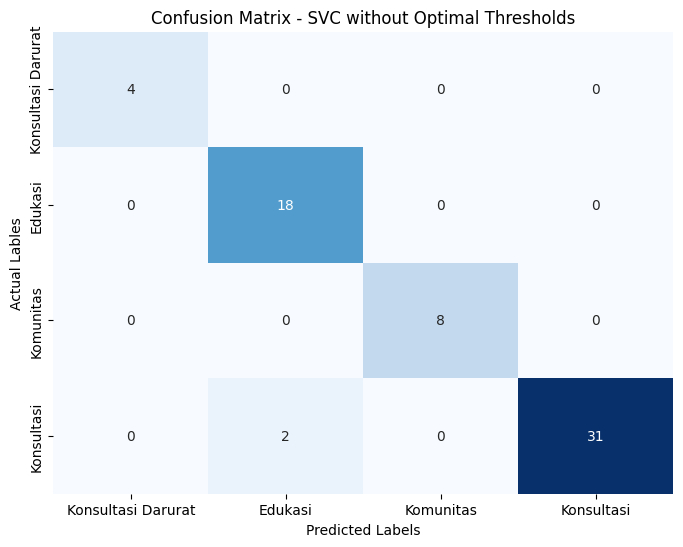

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       0.90      1.00      0.95        18
           2       1.00      1.00      1.00         8
           3       1.00      0.94      0.97        33

    accuracy                           0.97        63
   macro avg       0.97      0.98      0.98        63
weighted avg       0.97      0.97      0.97        63



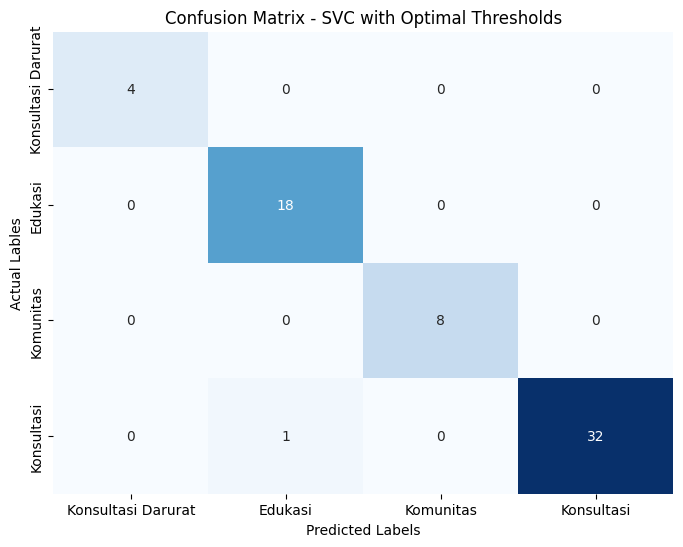

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       0.95      1.00      0.97        18
           2       1.00      1.00      1.00         8
           3       1.00      0.97      0.98        33

    accuracy                           0.98        63
   macro avg       0.99      0.99      0.99        63
weighted avg       0.98      0.98      0.98        63



In [42]:
X = df_cp["Postingan Keluhan"]
y = df_cp["Fitur"]

X_train_fitur, X_test_fitur, y_train_fitur, y_test_fitur = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

y_train_fitur = y_train_fitur.map({'Konsultasi Darurat': 0, 'Edukasi': 1, 'Komunitas': 2, 'Konsultasi': 3})
y_test_fitur = y_test_fitur.map({'Konsultasi Darurat': 0, 'Edukasi': 1, 'Komunitas': 2, 'Konsultasi': 3})

X_train_clean_fitur = X_train_fitur.apply(clean)
X_test_clean_fitur = X_test_fitur.apply(clean)

tfidf_fitur = TfidfVectorizer(ngram_range=(1, 2))

X_train_tfidf_fitur = tfidf_fitur.fit_transform(X_train_clean_fitur)
X_test_tfidf_fitur = tfidf_fitur.transform(X_test_clean_fitur)

smote_fitur = SMOTE(random_state=42)
X_train_resampled_fitur, y_train_resampled_fitur = smote_fitur.fit_resample(X_train_tfidf_fitur, y_train_fitur)

def classification_eval(actual, predict, name):
  cm = confusion_matrix(actual, predict)
  # plot confusion matrix
  plt.figure(figsize=(8,6))
  sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
              xticklabels=['Konsultasi Darurat', 'Edukasi', 'Komunitas', 'Konsultasi'],
              yticklabels=['Konsultasi Darurat', 'Edukasi', 'Komunitas', 'Konsultasi'])
  plt.xlabel('Predicted Labels')
  plt.ylabel('Actual Lables')
  plt.title(f'Confusion Matrix - {name}')
  plt.show()

  print(classification_report(actual, predict, zero_division=0))

svc_fitur = SVC(random_state=42, probability=True, kernel='linear')
model_fitur = svc_fitur.fit(X_train_resampled_fitur, y_train_resampled_fitur)

# threshold tuning
y_score_svc_train_fitur = model_fitur.predict_proba(X_train_resampled_fitur)

train_classes_fitur = [0, 1, 2, 3]
y_train_resampled_bin_fitur = label_binarize(y_train_resampled_fitur, classes=train_classes_fitur)

optimal_thresholds_svc_fitur, f1_scores_svc_fitur = get_optimal_thresholds(y_train_resampled_bin_fitur, y_score_svc_train_fitur)

print("\nOptimal Thresholds per Class (SVC) - derived from training data:")
class_names_fitur = ['Konsultasi Darurat', 'Edukasi', 'Komunitas', 'Konsultasi']
for i, class_name_fitur in enumerate(class_names_fitur):
    print(f"  {class_name_fitur} (Class {i}): {optimal_thresholds_svc_fitur[i]:.4f} (F1: {f1_scores_svc_fitur[i]:.4f})")

y_pred_test_fitur = model_fitur.predict(X_test_tfidf_fitur)
y_score_svc_test_fitur = model_fitur.predict_proba(X_test_tfidf_fitur)

y_pred_threshold_svc_fitur = apply_threshold_prediction(y_score_svc_test_fitur, optimal_thresholds_svc_fitur)

print("\n--- Performance Comparison (SVC) ---")
print(f"Accuracy (Default): {accuracy_score(y_test_fitur, y_pred_test_fitur):.4f}")
print(f"Accuracy (Threshold): {accuracy_score(y_test_fitur, y_pred_threshold_svc_fitur):.4f}")
print(f"Precision (Default): {precision_score(y_test_fitur, y_pred_test_fitur, average='weighted'):.4f}")
print(f"Precision (Threshold): {precision_score(y_test_fitur, y_pred_threshold_svc_fitur, average='weighted'):.4f}")
print(f"Recall (Default): {recall_score(y_test_fitur, y_pred_test_fitur, average='weighted'):.4f}")
print(f"Recall (Threshold): {recall_score(y_test_fitur, y_pred_threshold_svc_fitur, average='weighted'):.4f}")
print(f"F1-Score (Default): {f1_score(y_test_fitur, y_pred_test_fitur, average='weighted'):.4f}")
print(f"F1-Score (Threshold): {f1_score(y_test_fitur, y_pred_threshold_svc_fitur, average='weighted'):.4f}")

print("\n--- Confusion Matrix dengan Optimal Threshold (SVC) ---")
classification_eval(y_test_fitur, y_pred_test_fitur, 'SVC without Optimal Thresholds')

classification_eval(y_test_fitur, y_pred_threshold_svc_fitur, 'SVC with Optimal Thresholds')

In [43]:
import numpy as np
import pandas as pd

# 1. Ambil semua kosakata unik dari TF-IDF
feature_names_fitur = tfidf_fitur.get_feature_names_out()

# 2. Ambil matriks koefisien (bobot) dari SVC linear
# coef_ pada SVC berbentuk sparse matrix, kita ubah ke array biasa (.toarray())
svc_coefficients_fitur = model_fitur.coef_.toarray()

# 3. Inisialisasi matriks bobot agregat untuk setiap kelas (4 kelas x jumlah kata)
class_weights_fitur = np.zeros((4, len(feature_names_fitur)))

# Alur pencatatan koefisien OvO scikit-learn untuk 4 kelas secara berurutan adalah:
# (0 vs 1), (0 vs 2), (0 vs 3), (1 vs 2), (1 vs 3), (2 vs 3)
pair_idx_fitur = 0
for i in range(4):
    for j in range(i + 1, 4):
        # Nilai positif mendukung kelas i, nilai negatif mendukung kelas j
        class_weights_fitur[i] += svc_coefficients_fitur[pair_idx_fitur]
        class_weights_fitur[j] -= svc_coefficients_fitur[pair_idx_fitur]
        pair_idx_fitur += 1

# 4. Cetak 10 kata teratas untuk setiap kelas
class_names_fitur = ['Konsultasi Darurat', 'Edukasi', 'Komunitas', 'Konsultasi']

for class_idx_fitur, name_fitur in enumerate(class_names_fitur):
    print(f"\n📌 Kata Kunci Terpenting untuk Kelas: [{name_fitur}]")
    print("-" * 50)
    
    # Urutkan indeks bobot dari yang terbesar ke terkecil
    top_indices_fitur = np.argsort(class_weights_fitur[class_idx_fitur])[::-1][:20]
    
    for rank, idx in enumerate(top_indices_fitur, 1):
        word = feature_names_fitur[idx]
        weight = class_weights_fitur[class_idx_fitur][idx]
        print(f"{rank}. {word:<20} (Bobot: {weight:.4f})")


📌 Kata Kunci Terpenting untuk Kelas: [Konsultasi Darurat]
--------------------------------------------------
1. berat                (Bobot: 6.4899)
2. menyerah anak        (Bobot: 5.0664)
3. menyerah             (Bobot: 5.0664)
4. kuat                 (Bobot: 4.6668)
5. kuat menghadapi      (Bobot: 4.6668)
6. berat sulit          (Bobot: 2.8816)
7. menghadapi           (Bobot: 2.7362)
8. berat perilaku       (Bobot: 2.7092)
9. berat khawatir       (Bobot: 1.8266)
10. menghadapi kesulitan (Bobot: 1.7929)
11. menghadapi lingkungan (Bobot: 1.6712)
12. menghadapi kurangnya (Bobot: 1.2101)
13. menghadapi jadwal    (Bobot: 0.9167)
14. khawatir anak        (Bobot: 0.4342)
15. agresif              (Bobot: 0.3693)
16. perilaku agresif     (Bobot: 0.3693)
17. agresif anak         (Bobot: 0.3693)
18. malam                (Bobot: 0.3264)
19. sulit tidur          (Bobot: 0.3264)
20. tidur malam          (Bobot: 0.3264)

📌 Kata Kunci Terpenting untuk Kelas: [Edukasi]
------------------------------

# Masalah


Optimal Thresholds per Class (SVC) - derived from training data:
  Dukungan (Class 0): 0.3508 (F1: 0.9913)
  Gangguan Psikologis Pendamping (Class 1): 0.4226 (F1: 0.9907)
  Kebutuhan Informasi (Class 2): 0.8583 (F1: 0.9892)
  Masalah Lain (Class 3): 1.0000 (F1: 1.0000)

--- Performance Comparison (SVC) ---
Accuracy (Default): 0.8730
Accuracy (Threshold): 0.8730
Precision (Default): 0.8962
Precision (Threshold): 0.8962
Recall (Default): 0.8730
Recall (Threshold): 0.8730
F1-Score (Default): 0.8739
F1-Score (Threshold): 0.8739

--- Confusion Matrix dengan Optimal Threshold (SVC) ---


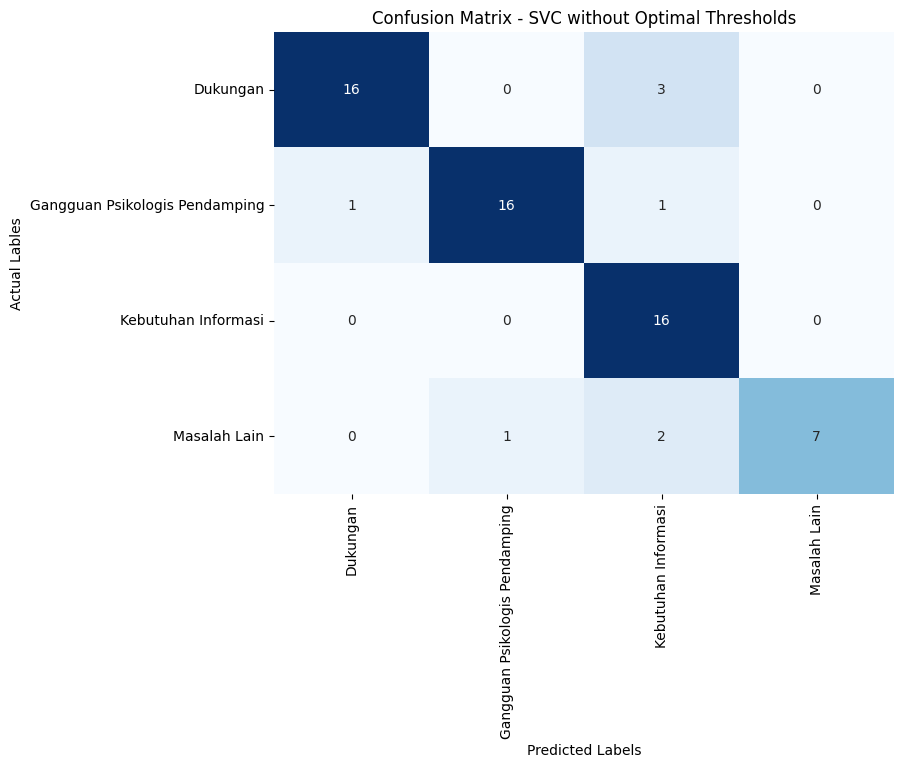

              precision    recall  f1-score   support

           0       0.94      0.84      0.89        19
           1       0.94      0.89      0.91        18
           2       0.73      1.00      0.84        16
           3       1.00      0.70      0.82        10

    accuracy                           0.87        63
   macro avg       0.90      0.86      0.87        63
weighted avg       0.90      0.87      0.87        63



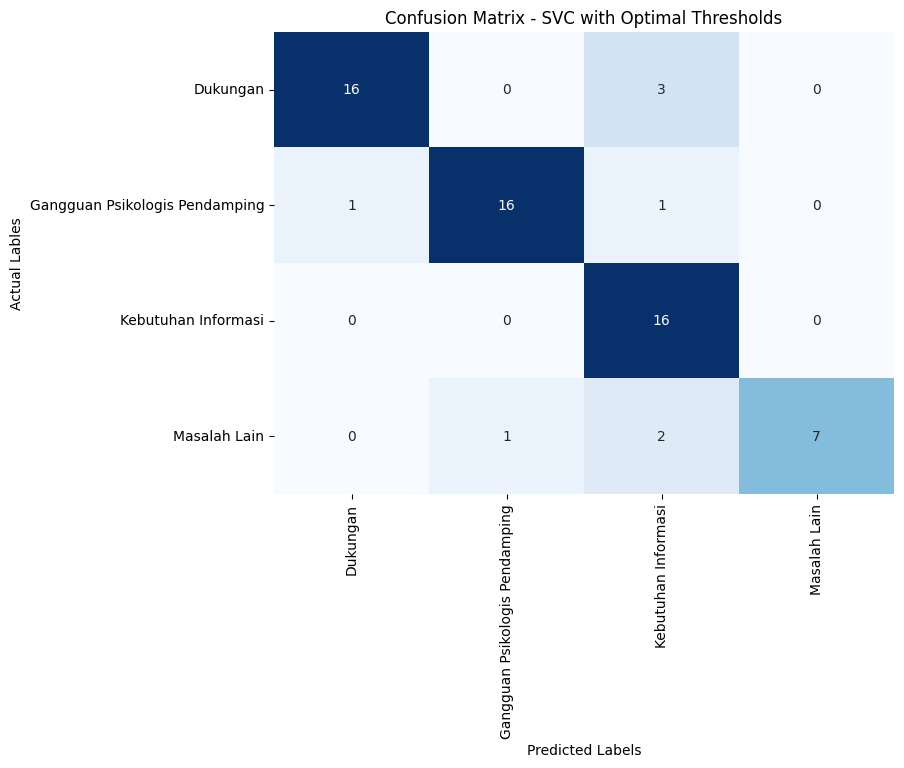

              precision    recall  f1-score   support

           0       0.94      0.84      0.89        19
           1       0.94      0.89      0.91        18
           2       0.73      1.00      0.84        16
           3       1.00      0.70      0.82        10

    accuracy                           0.87        63
   macro avg       0.90      0.86      0.87        63
weighted avg       0.90      0.87      0.87        63



In [44]:
# split data

X = df_cp["Postingan Keluhan"]
y = df_cp["Kategori Masalah"]

X_train_masalah, X_test_masalah, y_train_masalah, y_test_masalah = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

y_train_masalah = y_train_masalah.map({'Dukungan': 0, 'Gangguan Psikologis Pendamping': 1, 'Kebutuhan Informasi': 2, 'Masalah Lain': 3})
y_test_masalah = y_test_masalah.map({'Dukungan': 0, 'Gangguan Psikologis Pendamping': 1, 'Kebutuhan Informasi': 2, 'Masalah Lain': 3})

X_train_clean_masalah = X_train_masalah.apply(clean)
X_test_clean_masalah = X_test_masalah.apply(clean)

tfidf_masalah = TfidfVectorizer(ngram_range=(1, 2))

X_train_tfidf_masalah = tfidf_masalah.fit_transform(X_train_clean_masalah)
X_test_tfidf_masalah = tfidf_masalah.transform(X_test_clean_masalah)

def classification_eval(actual, predict, name):

  cm = confusion_matrix(actual, predict)
  # plot confusion matrix
  plt.figure(figsize=(8,6))
  sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
              xticklabels=['Dukungan', 'Gangguan Psikologis Pendamping', 'Kebutuhan Informasi', 'Masalah Lain'],
              yticklabels=['Dukungan', 'Gangguan Psikologis Pendamping', 'Kebutuhan Informasi', 'Masalah Lain'])
  plt.xlabel('Predicted Labels')
  plt.ylabel('Actual Lables')
  plt.title(f'Confusion Matrix - {name}')
  plt.show()

  print(classification_report(actual, predict, zero_division=0))

svc_masalah= SVC(random_state=42, probability=True, kernel='linear')
model_masalah = svc_masalah.fit(X_train_tfidf_masalah, y_train_masalah)

# threshold tuning
y_score_svc_train_masalah = model_masalah.predict_proba(X_train_tfidf_masalah)
train_classes_masalah = [0, 1, 2, 3]
y_train_resampled_bin_masalah = label_binarize(y_train_masalah, classes=train_classes_masalah)

optimal_thresholds_svc_masalah, f1_scores_svc_masalah = get_optimal_thresholds(y_train_resampled_bin_masalah, y_score_svc_train_masalah)

print("\nOptimal Thresholds per Class (SVC) - derived from training data:")
class_names_masalah = ['Dukungan', 'Gangguan Psikologis Pendamping', 'Kebutuhan Informasi', 'Masalah Lain']
for i, class_name_masalah in enumerate(class_names_masalah):
    print(f"  {class_name_masalah} (Class {i}): {optimal_thresholds_svc_masalah[i]:.4f} (F1: {f1_scores_svc_masalah[i]:.4f})")

y_pred_test_masalah = model_masalah.predict(X_test_tfidf_masalah)
y_score_svc_test_masalah = model_masalah.predict_proba(X_test_tfidf_masalah)

y_pred_threshold_svc_masalah = apply_threshold_prediction(y_score_svc_test_masalah, optimal_thresholds_svc_masalah)

print("\n--- Performance Comparison (SVC) ---")
print(f"Accuracy (Default): {accuracy_score(y_test_masalah, y_pred_test_masalah):.4f}")
print(f"Accuracy (Threshold): {accuracy_score(y_test_masalah, y_pred_threshold_svc_masalah):.4f}")
print(f"Precision (Default): {precision_score(y_test_masalah, y_pred_test_masalah, average='weighted'):.4f}")
print(f"Precision (Threshold): {precision_score(y_test_masalah, y_pred_threshold_svc_masalah, average='weighted'):.4f}")
print(f"Recall (Default): {recall_score(y_test_masalah, y_pred_test_masalah, average='weighted'):.4f}")
print(f"Recall (Threshold): {recall_score(y_test_masalah, y_pred_threshold_svc_masalah, average='weighted'):.4f}")
print(f"F1-Score (Default): {f1_score(y_test_masalah, y_pred_test_masalah, average='weighted'):.4f}")
print(f"F1-Score (Threshold): {f1_score(y_test_masalah, y_pred_threshold_svc_masalah, average='weighted'):.4f}")

print("\n--- Confusion Matrix dengan Optimal Threshold (SVC) ---")
classification_eval(y_test_masalah, y_pred_test_masalah, 'SVC without Optimal Thresholds')

classification_eval(y_test_masalah, y_pred_threshold_svc_masalah, 'SVC with Optimal Thresholds')


In [45]:
import numpy as np
import pandas as pd

# 1. Ambil semua kosakata unik dari TF-IDF
feature_names_masalah = tfidf_masalah.get_feature_names_out()

# 2. Ambil matriks koefisien (bobot) dari SVC linear
# coef_ pada SVC berbentuk sparse matrix, kita ubah ke array biasa (.toarray())
svc_coefficients_masalah = model_masalah.coef_.toarray()

# 3. Inisialisasi matriks bobot agregat untuk setiap kelas (4 kelas x jumlah kata)
class_weights_masalah = np.zeros((4, len(feature_names_masalah)))

# Alur pencatatan koefisien OvO scikit-learn untuk 4 kelas secara berurutan adalah:
# (0 vs 1), (0 vs 2), (0 vs 3), (1 vs 2), (1 vs 3), (2 vs 3)
pair_idx_masalah = 0
for i in range(4):
    for j in range(i + 1, 4):
        # Nilai positif mendukung kelas i, nilai negatif mendukung kelas j
        class_weights_masalah[i] += svc_coefficients_masalah[pair_idx_masalah]
        class_weights_masalah[j] -= svc_coefficients_masalah[pair_idx_masalah]
        pair_idx_masalah += 1

# 4. Cetak 10 kata teratas untuk setiap kelas
class_names_masalah = ['Dukungan', 'Gangguan Psikologis Pendamping', 'Kebutuhan Informasi', 'Masalah Lain']

for class_idx_masalah, name_masalah in enumerate(class_names_masalah):
    print(f"\n📌 Kata Kunci Terpenting untuk Kelas: [{name_masalah}]")
    print("-" * 50)
    
    # Urutkan indeks bobot dari yang terbesar ke terkecil
    top_indices_masalah = np.argsort(class_weights_masalah[class_idx_masalah])[::-1][:20]
    
    for rank, idx in enumerate(top_indices_masalah, 1):
        word = feature_names_masalah[idx]
        weight = class_weights_masalah[class_idx_masalah][idx]
        print(f"{rank}. {word:<20} (Bobot: {weight:.4f})")


📌 Kata Kunci Terpenting untuk Kelas: [Dukungan]
--------------------------------------------------
1. percaya              (Bobot: 2.9932)
2. orang                (Bobot: 2.5812)
3. pasangan             (Bobot: 2.3999)
4. dipahami             (Bobot: 2.3436)
5. dikucilkan           (Bobot: 2.2047)
6. dikucilkan anak      (Bobot: 2.2047)
7. terapi anak          (Bobot: 2.0961)
8. memengaruhi          (Bobot: 2.0687)
9. kelelahan            (Bobot: 1.8662)
10. kelelahan fisik      (Bobot: 1.8662)
11. fisik                (Bobot: 1.8662)
12. memiliki             (Bobot: 1.8181)
13. kesehatan menurun    (Bobot: 1.7772)
14. menurun              (Bobot: 1.7772)
15. kesehatan            (Bobot: 1.7772)
16. membutuhkan          (Bobot: 1.7412)
17. komentar             (Bobot: 1.6295)
18. komentar orang       (Bobot: 1.6295)
19. akibat               (Bobot: 1.5495)
20. tidur akibat         (Bobot: 1.5495)

📌 Kata Kunci Terpenting untuk Kelas: [Gangguan Psikologis Pendamping]
------------------

# Respon


Optimal Thresholds per Class (SVC) - derived from training data:
  0 (Class 0): 0.9837 (F1: 1.0000)
  1 (Class 1): 0.9138 (F1: 1.0000)
  2 (Class 2): 0.9593 (F1: 1.0000)
  3 (Class 3): 0.9635 (F1: 1.0000)
  4 (Class 4): 0.9542 (F1: 1.0000)

--- Performance Comparison (SVC) ---
Accuracy (Default): 0.9206
Accuracy (Threshold): 0.9206
Precision (Default): 0.9227
Precision (Threshold): 0.9227
Recall (Default): 0.9206
Recall (Threshold): 0.9206
F1-Score (Default): 0.9184
F1-Score (Threshold): 0.9184

--- Confusion Matrix dengan Optimal Threshold (SVC) ---


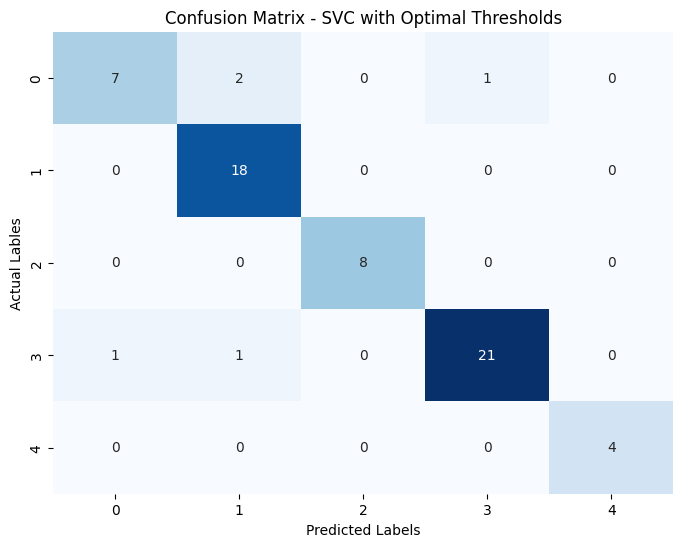

              precision    recall  f1-score   support

           0       0.88      0.70      0.78        10
           1       0.86      1.00      0.92        18
           2       1.00      1.00      1.00         8
           3       0.95      0.91      0.93        23
           4       1.00      1.00      1.00         4

    accuracy                           0.92        63
   macro avg       0.94      0.92      0.93        63
weighted avg       0.92      0.92      0.92        63



In [ ]:
X = df_cp["Postingan Keluhan"]
y = df_cp["Penjelasan masalah + kasus"]

X_train_respon, X_test_respon, y_train_respon, y_test_respon = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

y_train_respon = y_train_respon.map({ 'Untuk informasi lebih lanjut mengenai masalah tersebut, silakan melakukan konsultasi.': 0,
                        'Kesulitan memperoleh informasi yang jelas mengenai ASD dapat membuat caregiver merasa bingung dalam mengambil keputusan terkait pengasuhan maupun terapi. Memahami kondisi anak secara lebih baik dapat membantu meningkatkan kepercayaan diri dalam mendampingi anak sehari-hari. Anda dapat mengakses fitur Edukasi untuk memperoleh informasi dan materi yang relevan.': 1,
                        'Kurangnya dukungan dari lingkungan sekitar dapat membuat caregiver merasa sendirian dalam menghadapi berbagai tantangan pengasuhan. Berbagi pengalaman dengan orang lain yang memiliki situasi serupa sering kali membantu mengurangi beban emosional dan memberikan sudut pandang baru. Anda dapat memanfaatkan fitur Forum Komunitas untuk terhubung dengan caregiver lainnya.': 2,
                        'Saya memahami bahwa tanggung jawab pengasuhan yang terus-menerus dapat menimbulkan kelelahan fisik dan emosional. Banyak caregiver mengalami tekanan ketika harus membagi waktu antara kebutuhan anak dan aktivitas sehari-hari. Anda dapat memanfaatkan fitur Konsultasi untuk berdiskusi lebih lanjut mengenai strategi pengelolaan stres dan dukungan yang sesuai dengan kondisi Anda.': 3,
                        'Terima kasih telah berbagi cerita. Saya memahami bahwa situasi yang Anda hadapi tidak mudah dan dapat menimbulkan berbagai emosi. Perasaan yang Anda rasakan adalah hal yang wajar dan penting untuk mendapatkan dukungan yang sesuai. Jika Anda merasa sangat tertekan atau terdapat risiko membahayakan diri sendiri maupun orang lain, segera hubungi tenaga profesional atau layanan bantuan darurat.':4,
                        })
y_test_respon = y_test_respon.map({   'Untuk informasi lebih lanjut mengenai masalah tersebut, silakan melakukan konsultasi.': 0,
                        'Kesulitan memperoleh informasi yang jelas mengenai ASD dapat membuat caregiver merasa bingung dalam mengambil keputusan terkait pengasuhan maupun terapi. Memahami kondisi anak secara lebih baik dapat membantu meningkatkan kepercayaan diri dalam mendampingi anak sehari-hari. Anda dapat mengakses fitur Edukasi untuk memperoleh informasi dan materi yang relevan.': 1,
                        'Kurangnya dukungan dari lingkungan sekitar dapat membuat caregiver merasa sendirian dalam menghadapi berbagai tantangan pengasuhan. Berbagi pengalaman dengan orang lain yang memiliki situasi serupa sering kali membantu mengurangi beban emosional dan memberikan sudut pandang baru. Anda dapat memanfaatkan fitur Forum Komunitas untuk terhubung dengan caregiver lainnya.': 2,
                        'Saya memahami bahwa tanggung jawab pengasuhan yang terus-menerus dapat menimbulkan kelelahan fisik dan emosional. Banyak caregiver mengalami tekanan ketika harus membagi waktu antara kebutuhan anak dan aktivitas sehari-hari. Anda dapat memanfaatkan fitur Konsultasi untuk berdiskusi lebih lanjut mengenai strategi pengelolaan stres dan dukungan yang sesuai dengan kondisi Anda.': 3,
                        'Terima kasih telah berbagi cerita. Saya memahami bahwa situasi yang Anda hadapi tidak mudah dan dapat menimbulkan berbagai emosi. Perasaan yang Anda rasakan adalah hal yang wajar dan penting untuk mendapatkan dukungan yang sesuai. Jika Anda merasa sangat tertekan atau terdapat risiko membahayakan diri sendiri maupun orang lain, segera hubungi tenaga profesional atau layanan bantuan darurat.':4,
                        })

X_train_clean_respon = X_train_respon.apply(clean)
X_test_clean_respon = X_test_respon.apply(clean)

tfidf_respon = TfidfVectorizer(ngram_range=(1, 2))

X_train_tfidf_respon = tfidf_respon.fit_transform(X_train_clean_respon)
X_test_tfidf_respon = tfidf_respon.transform(X_test_clean_respon)

smote_respon = SMOTE(random_state=42)
X_train_resampled_respon, y_train_resampled_respon = smote_respon.fit_resample(X_train_tfidf_respon, y_train_respon)

def classification_eval(actual, predict, name):

  cm = confusion_matrix(actual, predict)
  # plot confusion matrix
  plt.figure(figsize=(8,6))
  sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
              xticklabels=['0', '1', '2', '3', '4'],
              yticklabels=['0', '1', '2', '3', '4'])
  plt.xlabel('Predicted Labels')
  plt.ylabel('Actual Lables')
  plt.title(f'Confusion Matrix - {name}')
  plt.show()

  print(classification_report(actual, predict, zero_division=0))

svc_respon = SVC(random_state=42, probability=True, kernel='linear')
model_respon = svc_respon.fit(X_train_resampled_respon, y_train_resampled_respon)

# threshold tuning
y_score_svc_train_respon = model_respon.predict_proba(X_train_resampled_respon)
train_classes_respon = [0, 1, 2, 3, 4]
y_train_resampled_bin_respon = label_binarize(y_train_resampled_respon, classes=train_classes_respon)

optimal_thresholds_svc_respon, f1_scores_svc_respon = get_optimal_thresholds(y_train_resampled_bin_respon, y_score_svc_train_respon, n_classes=len(train_classes_respon))

print("\nOptimal Thresholds per Class (SVC) - derived from training data:")
class_names_respon = ['0', '1', '2', '3', '4']
for i, class_name_respon in enumerate(class_names_respon):
    print(f"  {class_name_respon} (Class {i}): {optimal_thresholds_svc_respon[i]:.4f} (F1: {f1_scores_svc_respon[i]:.4f})")

y_pred_test_respon = model_respon.predict(X_test_tfidf_respon)
y_score_svc_test_respon = model_respon.predict_proba(X_test_tfidf_respon)

y_pred_threshold_svc_respon = apply_threshold_prediction(y_score_svc_test_respon, optimal_thresholds_svc_respon)

print("\n--- Performance Comparison (SVC) ---")
print(f"Accuracy (Default): {accuracy_score(y_test_respon, y_pred_test_respon):.4f}")
print(f"Accuracy (Threshold): {accuracy_score(y_test_respon, y_pred_threshold_svc_respon):.4f}")
print(f"Precision (Default): {precision_score(y_test_respon, y_pred_test_respon, average='weighted'):.4f}")
print(f"Precision (Threshold): {precision_score(y_test_respon, y_pred_threshold_svc_respon, average='weighted'):.4f}")
print(f"Recall (Default): {recall_score(y_test_respon, y_pred_test_respon, average='weighted'):.4f}")
print(f"Recall (Threshold): {recall_score(y_test_respon, y_pred_threshold_svc_respon, average='weighted'):.4f}")
print(f"F1-Score (Default): {f1_score(y_test_respon, y_pred_test_respon, average='weighted'):.4f}")
print(f"F1-Score (Threshold): {f1_score(y_test_respon, y_pred_threshold_svc_respon, average='weighted'):.4f}")

print("\n--- Confusion Matrix dengan Optimal Threshold (SVC) ---")
classification_eval(y_test_respon, y_pred_test_respon, 'SVC without Optimal Thresholds')

classification_eval(y_test_respon, y_pred_threshold_svc_respon, 'SVC with Optimal Thresholds')

In [47]:
import numpy as np
import pandas as pd

# 1. Ambil semua kosakata unik dari TF-IDF
feature_names_respon = tfidf_respon.get_feature_names_out()

# 2. Ambil matriks koefisien (bobot) dari SVC linear
# coef_ pada SVC berbentuk sparse matrix, kita ubah ke array biasa (.toarray())
svc_coefficients_respon = model_respon.coef_.toarray()

# 3. Inisialisasi matriks bobot agregat untuk setiap kelas (4 kelas x jumlah kata)
class_names_respon = ['Untuk informasi lebih lanjut mengenai masalah tersebut, silakan melakukan konsultasi.',
                        'Kesulitan memperoleh informasi yang jelas mengenai ASD dapat membuat caregiver merasa bingung dalam mengambil keputusan terkait pengasuhan maupun terapi. Memahami kondisi anak secara lebih baik dapat membantu meningkatkan kepercayaan diri dalam mendampingi anak sehari-hari. Anda dapat mengakses fitur Edukasi untuk memperoleh informasi dan materi yang relevan.',
                        'Kurangnya dukungan dari lingkungan sekitar dapat membuat caregiver merasa sendirian dalam menghadapi berbagai tantangan pengasuhan. Berbagi pengalaman dengan orang lain yang memiliki situasi serupa sering kali membantu mengurangi beban emosional dan memberikan sudut pandang baru. Anda dapat memanfaatkan fitur Forum Komunitas untuk terhubung dengan caregiver lainnya.',
                        'Saya memahami bahwa tanggung jawab pengasuhan yang terus-menerus dapat menimbulkan kelelahan fisik dan emosional. Banyak caregiver mengalami tekanan ketika harus membagi waktu antara kebutuhan anak dan aktivitas sehari-hari. Anda dapat memanfaatkan fitur Konsultasi untuk berdiskusi lebih lanjut mengenai strategi pengelolaan stres dan dukungan yang sesuai dengan kondisi Anda.',
                        'Terima kasih telah berbagi cerita. Saya memahami bahwa situasi yang Anda hadapi tidak mudah dan dapat menimbulkan berbagai emosi. Perasaan yang Anda rasakan adalah hal yang wajar dan penting untuk mendapatkan dukungan yang sesuai. Jika Anda merasa sangat tertekan atau terdapat risiko membahayakan diri sendiri maupun orang lain, segera hubungi tenaga profesional atau layanan bantuan darurat.']

n_classes = len(class_names_respon)

class_weights_respon = np.zeros((n_classes, len(feature_names_respon)))

# Alur pencatatan koefisien OvO scikit-learn untuk 4 kelas secara berurutan adalah:
# (0 vs 1), (0 vs 2), (0 vs 3), (1 vs 2), (1 vs 3), (2 vs 3)
pair_idx_respon = 0
for i in range(n_classes):
    for j in range(i + 1, n_classes):
        # Nilai positif mendukung kelas i, nilai negatif mendukung kelas j
        class_weights_respon[i] += svc_coefficients_respon[pair_idx_respon]
        class_weights_respon[j] -= svc_coefficients_respon[pair_idx_respon]
        pair_idx_respon += 1

# 4. Cetak 20 kata teratas untuk setiap kelas
for class_idx_respon, name_respon in enumerate(class_names_respon):
    # Biar output tidak terlalu penuh, kita potong teks kelas yang panjang saat dicetak sebagai judul
    short_name = name_respon[:80] + "..." if len(name_respon) > 80 else name_respon
    print(f"\n📌 Kata Kunci Terpenting untuk Kelas {class_idx_respon}: [{short_name}]")
    print("-" * 65)
    
    # Urutkan indeks bobot dari yang terbesar ke terkecil
    top_indices_respon = np.argsort(class_weights_respon[class_idx_respon])[::-1][:20]
    
    for rank, idx in enumerate(top_indices_respon, 1):
        word = feature_names_respon[idx]
        weight = class_weights_respon[class_idx_respon][idx]
        print(f"{rank:2d}. {word:<25} (Bobot: {weight:.4f})")


📌 Kata Kunci Terpenting untuk Kelas 0: [Untuk informasi lebih lanjut mengenai masalah tersebut, silakan melakukan konsul...]
-----------------------------------------------------------------
 1. pekerjaan                 (Bobot: 2.2031)
 2. kerja                     (Bobot: 2.1656)
 3. mengalami                 (Bobot: 1.6462)
 4. kebutuhan                 (Bobot: 1.4979)
 5. banyaknya                 (Bobot: 1.4772)
 6. terlambat                 (Bobot: 1.4313)
 7. kehilangan fokus          (Bobot: 1.4230)
 8. fokus rumah               (Bobot: 1.4230)
 9. tagihan listrik           (Bobot: 1.3399)
10. listrik                   (Bobot: 1.3399)
11. tagihan                   (Bobot: 1.3399)
12. produktif                 (Bobot: 1.3399)
13. seharian                  (Bobot: 1.3399)
14. produktif seharian        (Bobot: 1.3399)
15. rumah                     (Bobot: 1.3283)
16. budget                    (Bobot: 1.3159)
17. tinggal sesuai            (Bobot: 1.3159)
18. tinggal               